# Exercise 16: Model selection

This homework is designed to give you practice implementing model selection techniques, including best subset selection and forward/backward stepwise selection.

You won't need to load in any data for this homework, we will be simulating our own.

---
## 1. Best subset selection (4 points)

In this question, we will first generate simulated data, and then use it to perform best subset selection.

a) Use `rnorm()` to generate a dataset including a predictor $X$ of length $n = 100$ and a noise vector $\epsilon$ of length $n = 100$. Generate data for a response variable $Y$ of length $n = 100$ according to the model

$Y = \beta_0 + \beta_1X + \beta_2X^2 + \beta_3X^3 + \epsilon$

where $\beta_0$, $\beta_1$, $\beta_2$, and $\beta_3$ are constants of your choice.


In [87]:
set.seed(15)

X = rnorm(100) #predictors
e = rnorm(100)#, mean = 0) #noise

beta0 = 5
beta1 = 0.2 #weak effect
beta2 = 0.5 #medium effect
beta3 = 0.7 #strong effect

Y = beta0 + beta1*(X^1) + beta2*(X^2) + beta3*(X^3) + e

b) Use `regsubsets()` to perform best subset selection to determine the best model that contains the predictor variables $X$, $X^2$, . . . , $X^{10}$. Print the model summary.

In [88]:
#install.packages("leaps")
library(leaps)

X_mat = data.frame( #chatGPT helped me with this part
  X1 = X,
  X2 = X^2,
  X3 = X^3,
  X4 = X^4,
  X5 = X^5,
  X6 = X^6,
  X7 = X^7,
  X8 = X^8,
  X9 = X^9,
  X10 = X^10
)
    
regfit.10 = regsubsets(Y ~ ., data = X_mat, nvmax = 10)
reg.summary = summary(regfit.10)
reg.summary

Subset selection object
Call: regsubsets.formula(Y ~ ., data = X_mat, nvmax = 10)
10 Variables  (and intercept)
    Forced in Forced out
X1      FALSE      FALSE
X2      FALSE      FALSE
X3      FALSE      FALSE
X4      FALSE      FALSE
X5      FALSE      FALSE
X6      FALSE      FALSE
X7      FALSE      FALSE
X8      FALSE      FALSE
X9      FALSE      FALSE
X10     FALSE      FALSE
1 subsets of each size up to 10
Selection Algorithm: exhaustive
          X1  X2  X3  X4  X5  X6  X7  X8  X9  X10
1  ( 1 )  " " " " "*" " " " " " " " " " " " " " "
2  ( 1 )  " " "*" "*" " " " " " " " " " " " " " "
3  ( 1 )  " " "*" "*" " " " " "*" " " " " " " " "
4  ( 1 )  " " "*" "*" " " "*" "*" " " " " " " " "
5  ( 1 )  " " " " "*" "*" " " "*" " " "*" " " "*"
6  ( 1 )  " " " " "*" "*" "*" "*" " " "*" " " "*"
7  ( 1 )  " " "*" "*" "*" "*" "*" " " "*" " " "*"
8  ( 1 )  " " "*" "*" "*" " " "*" "*" "*" "*" "*"
9  ( 1 )  " " "*" "*" "*" "*" "*" "*" "*" "*" "*"
10  ( 1 ) "*" "*" "*" "*" "*" "*" "*" "*" "*" "*"

c) Plot the Mallows' Cp, Bayesian Information Criteria (BIC) and the adjusted coefficient of determination, $R^2$, for each model tested. Based on each criterion, identify the best model size. Report the coefficients of the best model.

[1] "coefficient for maximum R^2: 0.87286792295157"


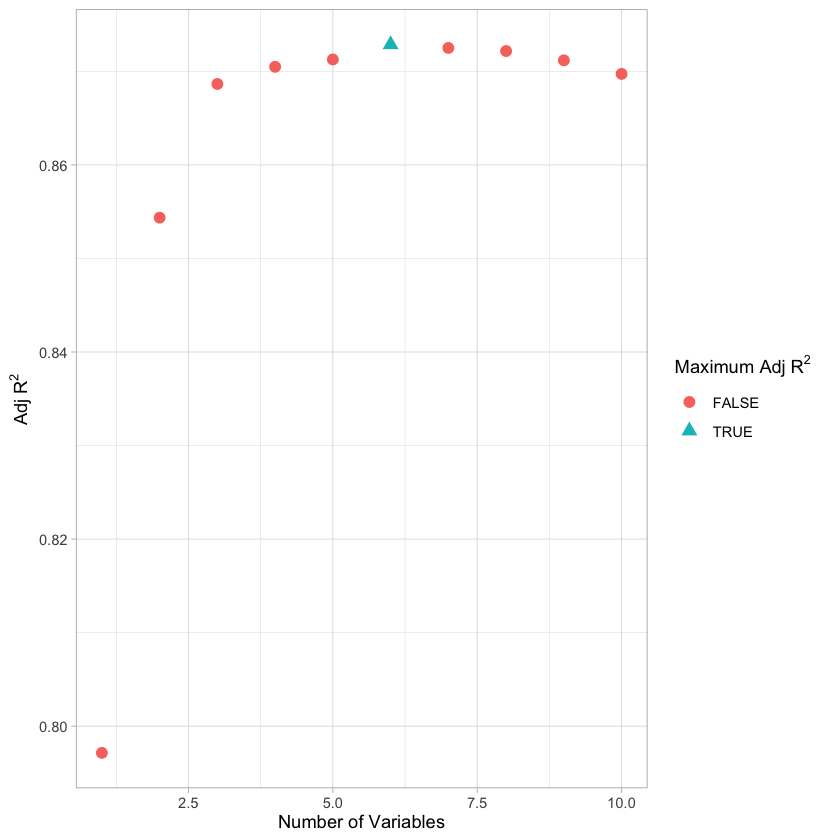

[1] "Lowest Mallow's CP: 4.44907982641327"


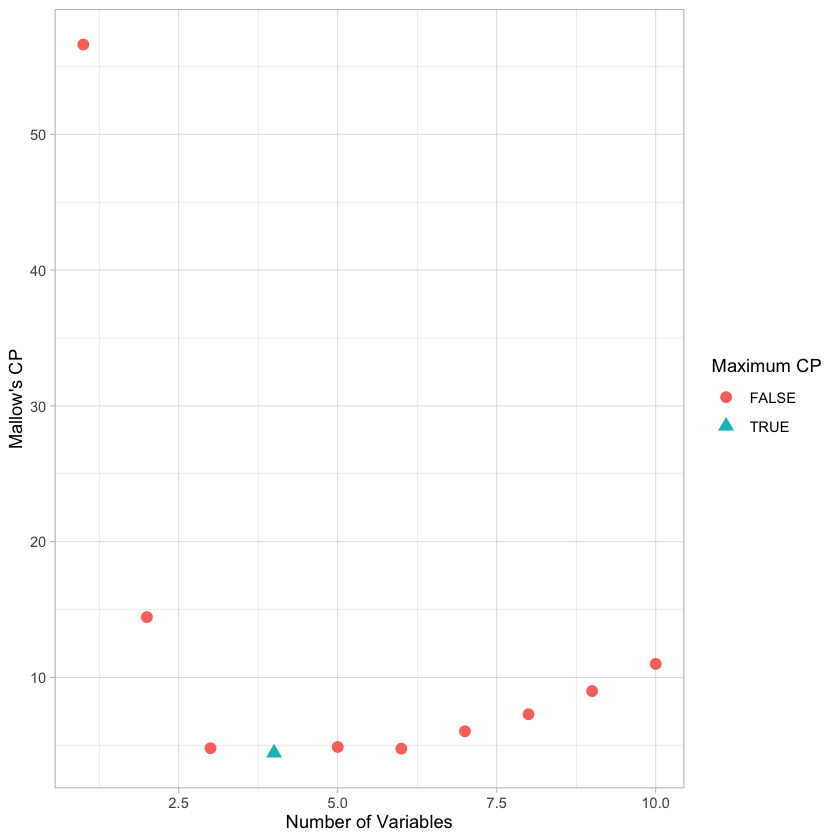

[1] "Lowest BIC: -187.647695492259"


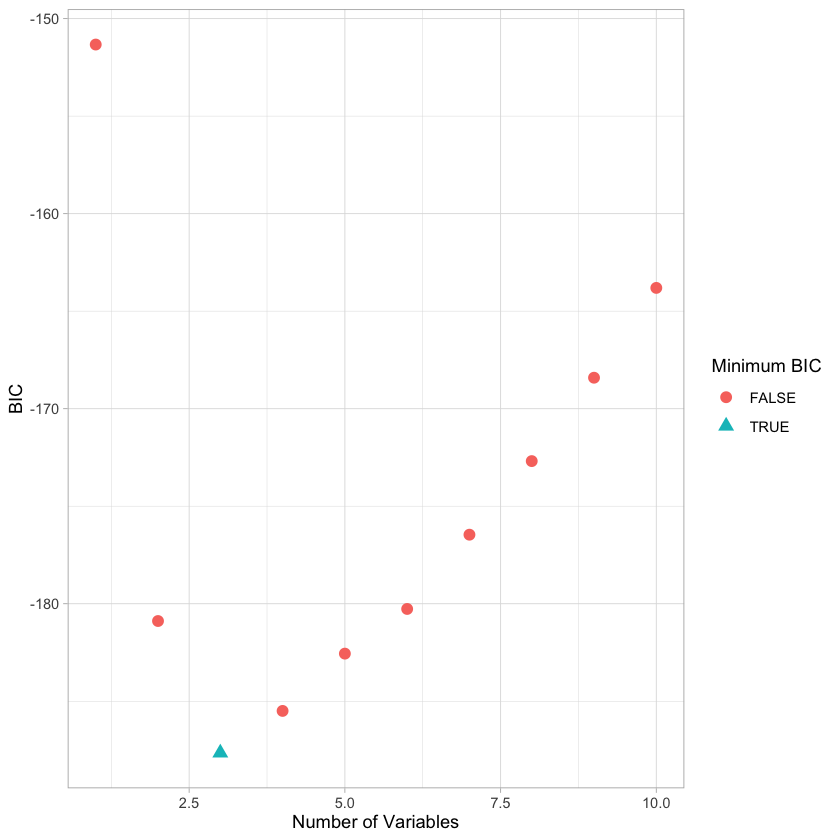

In [89]:
library(ggplot2)
numvar = 1:length(reg.summary$rss)# Make a vector that lists the number of variables in sequence, from 1 to 19. 
allfalse = rep(FALSE,length(reg.summary$rss))# Starting point for an indicator that marks the best model choice for each metric.

# #rss
# rss.df <- data.frame(numvar = numvar, rss = reg.summary$rss, minrss = allfalse)
# rss.df$minrss[which.min(reg.summary$rss)] <- TRUE
# ggplot(rss.df,aes(x=numvar,y=rss,shape=minrss,col=minrss)) + 
#     geom_point(size=3) + theme_light() + 
#     labs(x = "Number of Variables", y = "RSS", color="Minimum RSS", shape="Minimum RSS")

#adjr2
adjr2.df <- data.frame(numvar = numvar, adjr2 <- reg.summary$adjr2, maxadjr2 <- allfalse)
adjr2.df$maxadjr2[which.max(reg.summary$adjr2)] <- TRUE
ggplot(adjr2.df,aes(x=numvar,y=adjr2,shape=maxadjr2,col=maxadjr2)) + 
    geom_point(size=3) + theme_light() + 
    labs(x = "Number of Variables", y = 'Adj'~R^2, color='Maximum Adj'~R^2, shape='Maximum Adj'~R^2)
print(paste0("coefficient for maximum R^2: ", max(adjr2))) #I got syntax for this from chatGPT

#mallow's cp
cp.df <- data.frame(numvar = numvar, cp <- reg.summary$cp, mincp <- allfalse)
cp.df$mincp[which.min(reg.summary$cp)] <- TRUE
ggplot(cp.df,aes(x=numvar,y=cp,shape=mincp,col=mincp)) + 
    geom_point(size=3) + theme_light() + 
    labs(x = "Number of Variables", y = "Mallow's CP", color="Maximum CP", shape="Maximum CP")
print(paste0("Lowest Mallow's CP: ", min(cp)))


#bic
bic.df <- data.frame(numvar = numvar,bic <- reg.summary$bic, minbic <- allfalse)
bic.df$minbic[which.min(reg.summary$bic)] <- TRUE
ggplot(bic.df,aes(x=numvar,y=bic,shape=minbic,col=minbic)) + 
    geom_point(size=3) + theme_light() + 
    labs(x = "Number of Variables", y = "BIC", color="Minimum BIC", shape="Minimum BIC")
print(paste0("Lowest BIC: ", min(bic)))


> Based on the R^2, the best model is that with 6 variables, as it has the highest explained R^2 (0.873). According to Mallow's CP, the model with 4 variables is best, with the minimum Mallow's CP score of 4.449. According to BIC, the model with 3 variables is best, with the lowest BIC score of -187.648, compared to the other candidate models.


---
## 2. Forward and backwards stepwise selection (3 points)

Using the same simulated data from question 1, use forward stepwise selection, and backwards stepwise selections to identify the best model under each criterion. Again, for both model selection methods, plot the Mallows' Cp, Bayesian Information Criteria (BIC) and the adjusted coefficient of determination, $R^2$, for each model tested. Report the coefficients of the best model.

a) Forward stepwise selection:

In [90]:
#calculating forward stepwise selection
regfit.fwd = regsubsets(Y ~ ., data = X_mat, nvmax = 10, method = "forward")
reg.fwd_summary = summary(regfit.fwd)
reg.fwd_summary

Subset selection object
Call: regsubsets.formula(Y ~ ., data = X_mat, nvmax = 10, method = "forward")
10 Variables  (and intercept)
    Forced in Forced out
X1      FALSE      FALSE
X2      FALSE      FALSE
X3      FALSE      FALSE
X4      FALSE      FALSE
X5      FALSE      FALSE
X6      FALSE      FALSE
X7      FALSE      FALSE
X8      FALSE      FALSE
X9      FALSE      FALSE
X10     FALSE      FALSE
1 subsets of each size up to 10
Selection Algorithm: forward
          X1  X2  X3  X4  X5  X6  X7  X8  X9  X10
1  ( 1 )  " " " " "*" " " " " " " " " " " " " " "
2  ( 1 )  " " "*" "*" " " " " " " " " " " " " " "
3  ( 1 )  " " "*" "*" " " " " "*" " " " " " " " "
4  ( 1 )  " " "*" "*" " " "*" "*" " " " " " " " "
5  ( 1 )  " " "*" "*" " " "*" "*" "*" " " " " " "
6  ( 1 )  " " "*" "*" " " "*" "*" "*" " " "*" " "
7  ( 1 )  "*" "*" "*" " " "*" "*" "*" " " "*" " "
8  ( 1 )  "*" "*" "*" " " "*" "*" "*" "*" "*" " "
9  ( 1 )  "*" "*" "*" "*" "*" "*" "*" "*" "*" " "
10  ( 1 ) "*" "*" "*" "*" "*" "*

[1] "coefficient for maximum R^2: 0.870487814477074"


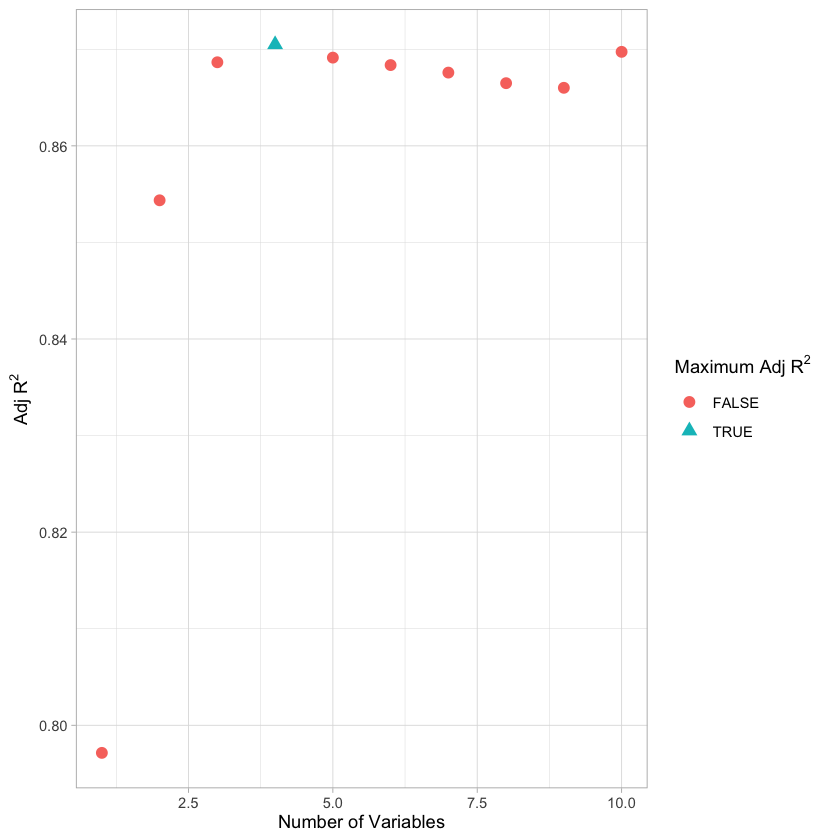

[1] "Lowest Mallow's CP: 4.44907982641328"


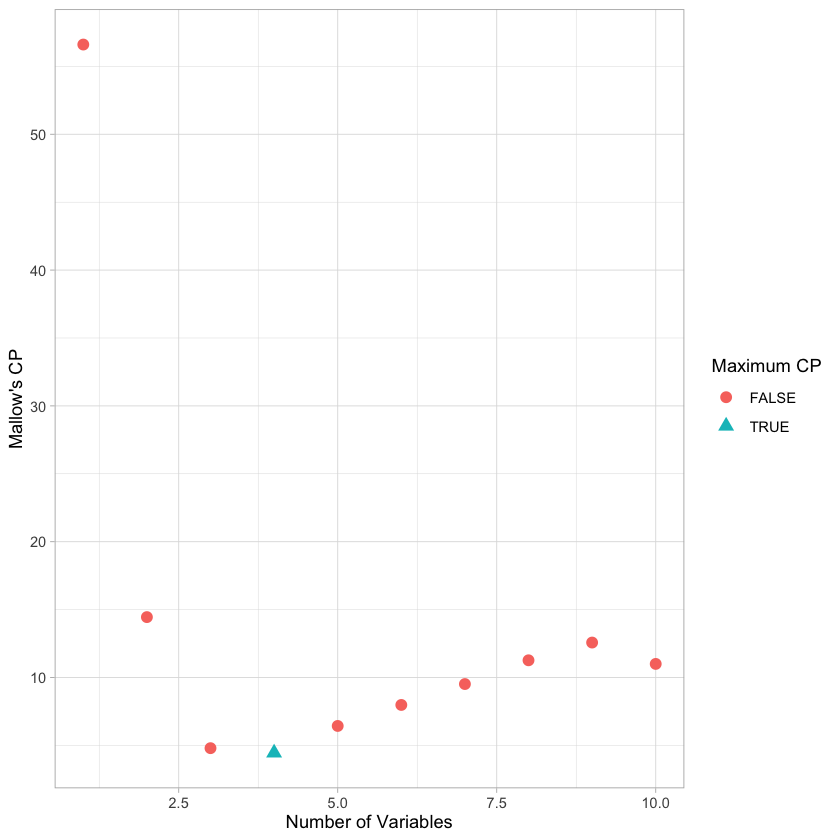

[1] "Lowest BIC: -187.647695492259"


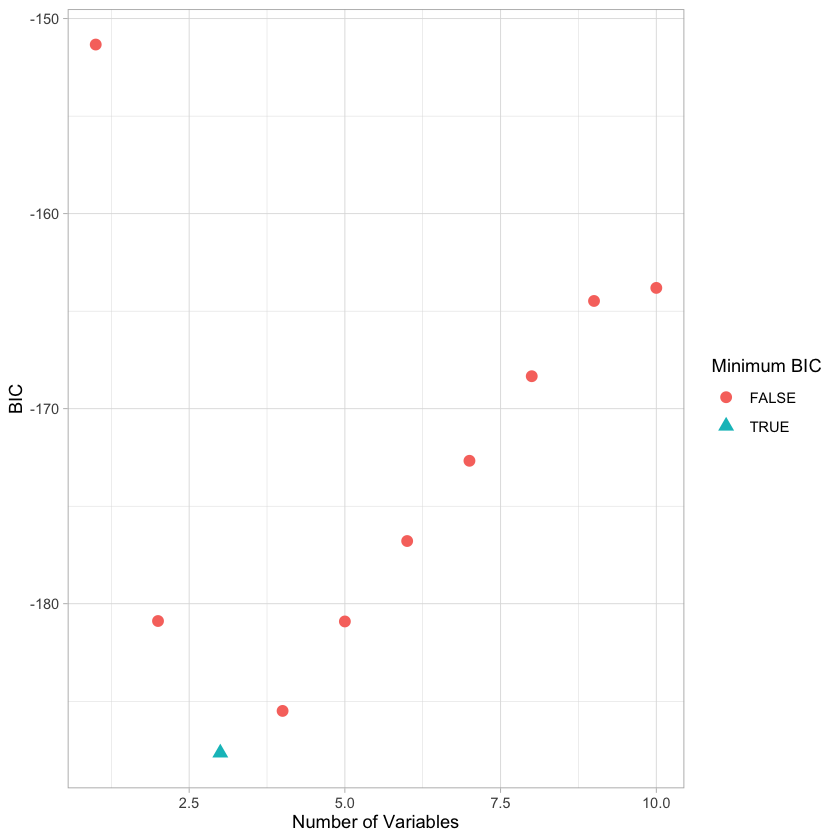

In [94]:
#plotting FORWARD stepwise selection
rm(reg.summary) #reset rm.summary and reassign to results from forward selection
reg.summary = reg.fwd_summary 
numvar = 1:length(reg.summary$rss)# Make a vector that lists the number of variables in sequence, from 1 to 19. 
allfalse = rep(FALSE,length(reg.summary$rss))# Starting point for an indicator that marks the best model choice for each metric.

# #rss
# rss.df <- data.frame(numvar = numvar, rss = reg.summary$rss, minrss = allfalse)
# rss.df$minrss[which.min(reg.summary$rss)] <- TRUE
# ggplot(rss.df,aes(x=numvar,y=rss,shape=minrss,col=minrss)) + 
#     geom_point(size=3) + theme_light() + 
#     labs(x = "Number of Variables", y = "RSS", color="Minimum RSS", shape="Minimum RSS")

#adjr2
adjr2.df <- data.frame(numvar = numvar, adjr2 <- reg.summary$adjr2, maxadjr2 <- allfalse)
adjr2.df$maxadjr2[which.max(reg.summary$adjr2)] <- TRUE
ggplot(adjr2.df,aes(x=numvar,y=adjr2,shape=maxadjr2,col=maxadjr2)) + 
    geom_point(size=3) + theme_light() + 
    labs(x = "Number of Variables", y = 'Adj'~R^2, color='Maximum Adj'~R^2, shape='Maximum Adj'~R^2)
print(paste0("coefficient for maximum R^2: ", max(adjr2))) #I got syntax for this from chatGPT

#mallow's cp
cp.df <- data.frame(numvar = numvar, cp <- reg.summary$cp, mincp <- allfalse)
cp.df$mincp[which.min(reg.summary$cp)] <- TRUE
ggplot(cp.df,aes(x=numvar,y=cp,shape=mincp,col=mincp)) + 
    geom_point(size=3) + theme_light() + 
    labs(x = "Number of Variables", y = "Mallow's CP", color="Maximum CP", shape="Maximum CP")
print(paste0("Lowest Mallow's CP: ", min(cp)))


#bic
bic.df <- data.frame(numvar = numvar,bic <- reg.summary$bic, minbic <- allfalse)
bic.df$minbic[which.min(reg.summary$bic)] <- TRUE
ggplot(bic.df,aes(x=numvar,y=bic,shape=minbic,col=minbic)) + 
    geom_point(size=3) + theme_light() + 
    labs(x = "Number of Variables", y = "BIC", color="Minimum BIC", shape="Minimum BIC")
print(paste0("Lowest BIC: ", min(bic)))


> Using forward selection yields the following results: the model with 4 variables has the highest R^2, at 0.870. Model 4 also has the lowest Mallow's CP, at 4.449. But model 3 has the lowest BIC, at -187.648. 


b) Backwards stepwise selection:

In [95]:
#calculating backward stepwise selection
regfit.bwd = regsubsets(Y ~ ., data = X_mat, nvmax = 10, method = "backward")
reg.bwd_summary = summary(regfit.bwd)
reg.bwd_summary

Subset selection object
Call: regsubsets.formula(Y ~ ., data = X_mat, nvmax = 10, method = "backward")
10 Variables  (and intercept)
    Forced in Forced out
X1      FALSE      FALSE
X2      FALSE      FALSE
X3      FALSE      FALSE
X4      FALSE      FALSE
X5      FALSE      FALSE
X6      FALSE      FALSE
X7      FALSE      FALSE
X8      FALSE      FALSE
X9      FALSE      FALSE
X10     FALSE      FALSE
1 subsets of each size up to 10
Selection Algorithm: backward
          X1  X2  X3  X4  X5  X6  X7  X8  X9  X10
1  ( 1 )  " " " " "*" " " " " " " " " " " " " " "
2  ( 1 )  " " " " "*" "*" " " " " " " " " " " " "
3  ( 1 )  " " " " "*" "*" " " "*" " " " " " " " "
4  ( 1 )  " " " " "*" "*" " " "*" " " "*" " " " "
5  ( 1 )  " " " " "*" "*" " " "*" " " "*" " " "*"
6  ( 1 )  " " " " "*" "*" " " "*" "*" "*" " " "*"
7  ( 1 )  " " " " "*" "*" " " "*" "*" "*" "*" "*"
8  ( 1 )  " " "*" "*" "*" " " "*" "*" "*" "*" "*"
9  ( 1 )  " " "*" "*" "*" "*" "*" "*" "*" "*" "*"
10  ( 1 ) "*" "*" "*" "*" "*" 

[1] "coefficient for maximum R^2: 0.872523685443207"


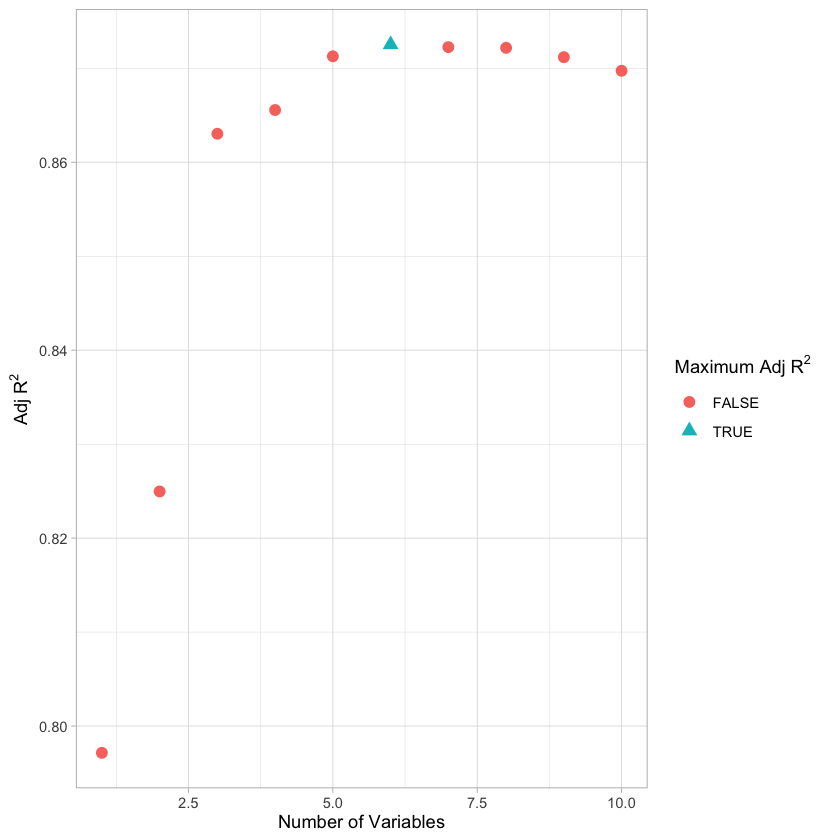

[1] "Lowest Mallow's CP: 4.8866822418105"


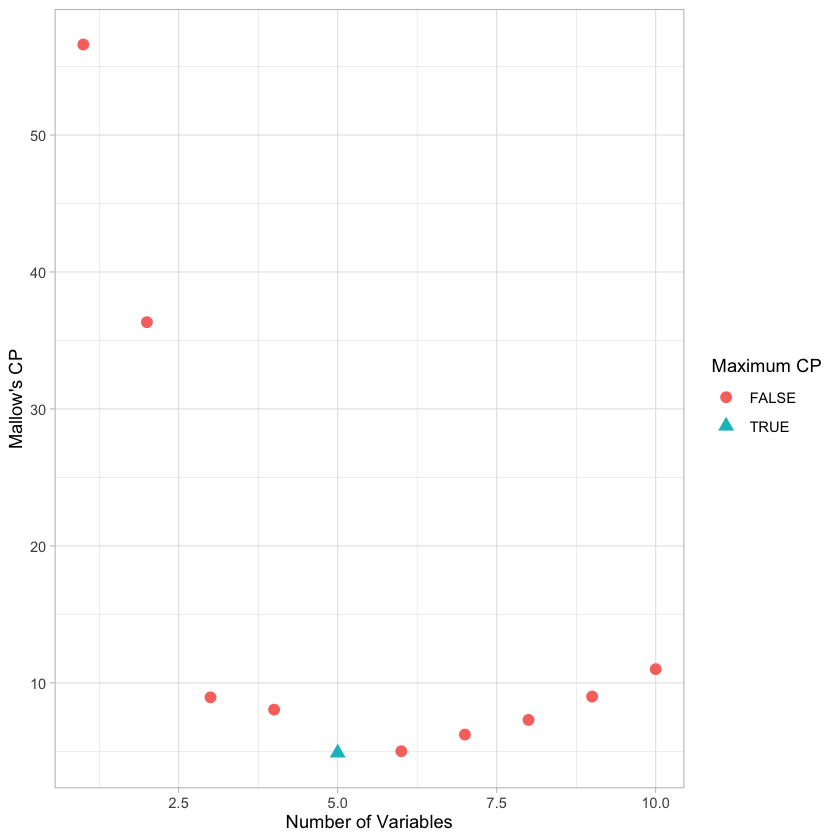

[1] "Lowest BIC: -183.45564797829"


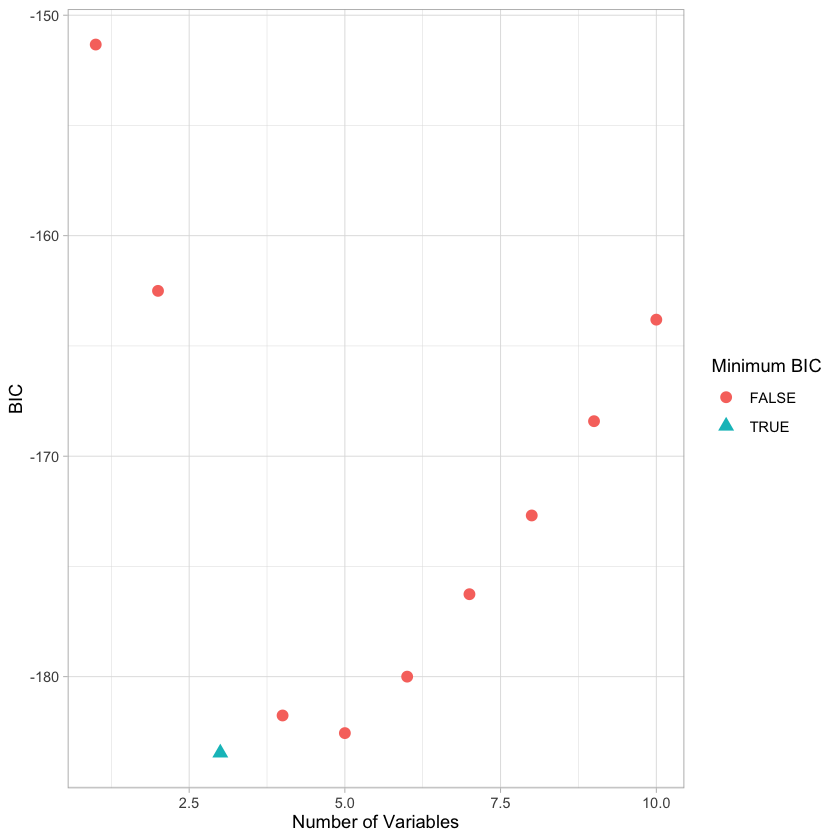

In [97]:
#plotting BACKWARD stepwise selection
rm(reg.summary) #reset rm.summary and reassign to results from forward selection
reg.summary = reg.bwd_summary #reassign reg.summary to results from forward selection
numvar = 1:length(reg.summary$rss)# Make a vector that lists the number of variables in sequence, from 1 to 19. 
allfalse = rep(FALSE,length(reg.summary$rss))# Starting point for an indicator that marks the best model choice for each metric.

# #rss
# rss.df <- data.frame(numvar = numvar, rss = reg.summary$rss, minrss = allfalse)
# rss.df$minrss[which.min(reg.summary$rss)] <- TRUE
# ggplot(rss.df,aes(x=numvar,y=rss,shape=minrss,col=minrss)) + 
#     geom_point(size=3) + theme_light() + 
#     labs(x = "Number of Variables", y = "RSS", color="Minimum RSS", shape="Minimum RSS")

#adjr2
adjr2.df <- data.frame(numvar = numvar, adjr2 <- reg.summary$adjr2, maxadjr2 <- allfalse)
adjr2.df$maxadjr2[which.max(reg.summary$adjr2)] <- TRUE
ggplot(adjr2.df,aes(x=numvar,y=adjr2,shape=maxadjr2,col=maxadjr2)) + 
    geom_point(size=3) + theme_light() + 
    labs(x = "Number of Variables", y = 'Adj'~R^2, color='Maximum Adj'~R^2, shape='Maximum Adj'~R^2)
print(paste0("coefficient for maximum R^2: ", max(adjr2))) #I got syntax for this from chatGPT

#mallow's cp
cp.df <- data.frame(numvar = numvar, cp <- reg.summary$cp, mincp <- allfalse)
cp.df$mincp[which.min(reg.summary$cp)] <- TRUE
ggplot(cp.df,aes(x=numvar,y=cp,shape=mincp,col=mincp)) + 
    geom_point(size=3) + theme_light() + 
    labs(x = "Number of Variables", y = "Mallow's CP", color="Maximum CP", shape="Maximum CP")
print(paste0("Lowest Mallow's CP: ", min(cp)))


#bic
bic.df <- data.frame(numvar = numvar,bic <- reg.summary$bic, minbic <- allfalse)
bic.df$minbic[which.min(reg.summary$bic)] <- TRUE
ggplot(bic.df,aes(x=numvar,y=bic,shape=minbic,col=minbic)) + 
    geom_point(size=3) + theme_light() + 
    labs(x = "Number of Variables", y = "BIC", color="Minimum BIC", shape="Minimum BIC")
print(paste0("Lowest BIC: ", min(bic)))


c) Compare your results from parts a and b with those of question 1. Did the two methods select similar model sizes and predictors? If not, how did they differ?

> Using backward selection yields the following results: the model with 6 variables has the highest R^2, at 0.873. Model 4 has the lowest Mallow's CP, at 4.887. But model 3 has the lowest BIC, at -187.648.


> All 3 methods "agree" that the best model based on BIC is that with 3 variables (where forward and the original method from Q1 had an identical BIC score, whereas backward method's BIC score was slightly different). The backward model agrees with that from Q1 for R^2, both selecting the 6-parameter model as best, with an identical R^2 score, while forward selection chooses the 4-parameter model. Forward selection agrees with the model from Q1 based on Mallow's CP: they both select the 4-parameter model as best, with identical scores, whereas the backward model selects the 5-parameter model. 

---
## 3. Training and test error (3 points)

This question will explore the relationship between training and test error and the number of features included in a model. We will again use a simulated dataset.

a) Simulate dataset with features $p = 20$ and observations $n = 1,000$. Generate data for a response variable $Y$ according to the model

$Y = X\beta + \epsilon$

where $\beta$ is random with some elements that are exactly zero.

Split your simulated dataset into a training set containing $n=100$ observations and a test set containing $n=900$ observations.

In [114]:
set.seed(15)
p <- matrix(NA, nrow = 1000, ncol = 20)
X0 = rnorm(1000) #initial X that will be taken to 19 powers to create each polynomial parameter
e = rnorm(1000) 

for (i in 1:ncol(p)) {
    X_idx = i
    X = X0^X_idx
    p[, i] = X #p will have 1000 observations (rows) and 20 features (columns) 
    rm(X) #remove X just in case so it can be recreated in next iteration
    } 

set.seed(15)

#create random betas where 10 values are random and 10 are 0. I asked chatGPT to help me with this 
betas = rep(0, 20)
# Choose which positions are non-zero
nonzero_idx = sample(1:20, 10)  
# Assign random values to those positions
betas[nonzero_idx] = rnorm(10)

Y = betas * p + e 
#dim(Y)

train = Y[1:900, ]
test = Y[901:1000, ]

b) Perform best subset selection on the training set, and plot the associated training and test set MSE for the best model of each size.

ERROR: Error in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, : y and x different lengths


c) Identify the best model according to the test MSE. How does this model compare to the actual model used to simulate the dataset?

*Note: If the model identified contains only an intercept or all of the features, then generate a new dataset (i.e. repeat part a with a different random seed) until the test set MSE is minimized for an intermediate model size.*

In [ ]:
# WRITE YOUR CODE HERE



> *Write your response here*
>

**DUE:** 11:59pm EST, April 2, 2026

**IMPORTANT** Did you collaborate with anyone on this assignment? If so, list their names here.
> *Someone's Name*